# 1. Introduction

## 1.1 Background and SISA explained

Notebook 01 created the original baseline. Notebook 02 fixed the deletion scenarios and full-retraining references. Notebook 03 evaluated fine-tuning, and Notebook 04 evaluated gradient ascent. Notebook 05 evaluates **SISA: Sharded, Isolated, Sliced and Aggregated training**.

Training recipients are divided into separate shards. Each shard model is trained independently through ordered slices, and their probabilities are averaged. When deletion is requested, only affected shard portions are replayed. SISA does not edit the Notebook 01 baseline; it prepares its own five-model ensemble from fresh seeded parameters.


In [1]:
import pandas as pd
from IPython.display import display

sisa_terms = pd.DataFrame([
    {"term": "Sharded", "meaning": "training recipients are partitioned across independent models"},
    {"term": "Isolated", "meaning": "a shard is trained without records assigned to other shards"},
    {"term": "Sliced", "meaning": "each shard is learned through five replayable stages"},
    {"term": "Aggregated", "meaning": "five shard probabilities are averaged with equal weights"},
])
display(sisa_terms)

,term,meaning
0,Sharded,training recipients are partitioned across ind...
1,Isolated,a shard is trained without records assigned to...
2,Sliced,each shard is learned through five replayable ...
3,Aggregated,five shard probabilities are averaged with equ...


## 1.2 Research aim and questions

The aim is to determine whether SISA supports efficient selective deletion while preserving utility and approximating full-retraining behaviour.

1. How many shards and slices does each deletion affect?
2. How much retained utility is preserved?
3. How similar is updated SISA to full retraining on forget records?
4. How does SISA compare with fine-tuning and gradient ascent?
5. What is the deletion-time saving?
6. What initial training and storage cost is required?


In [2]:
study_design = pd.DataFrame([
    {"objective": "Deletion structure", "evaluation": "affected shards and replayed stages", "comparison": "five fixed scenarios"},
    {"objective": "Retained utility", "evaluation": "held-out retained-test metrics", "comparison": "four existing methods and original SISA"},
    {"objective": "Forget behaviour", "evaluation": "truth-ratio KS and supporting measures", "comparison": "full retraining, fine-tuning, gradient ascent"},
    {"objective": "Efficiency", "evaluation": "preparation, replay time and storage", "comparison": "full retraining, fine-tuning, gradient ascent"},
])
display(study_design)

,objective,evaluation,comparison
0,Deletion structure,affected shards and replayed stages,five fixed scenarios
1,Retained utility,held-out retained-test metrics,four existing methods and original SISA
2,Forget behaviour,truth-ratio KS and supporting measures,"full retraining, fine-tuning, gradient ascent"
3,Efficiency,"preparation, replay time and storage","full retraining, fine-tuning, gradient ascent"


## 1.3 Scope boundaries

The authoritative dataset, permanent splits and five deletion scenarios remain unchanged. Complete recipient histories stay together. Shard and slice assignments are fixed before deletion evaluation, and threshold `0.62` is retained. Existing methods are read-only references. Initial preparation and deletion-time cost are reported separately. Output similarity is not proof of erasure or privacy, and generated-data results are not clinical evidence.


# 2. Setup and reproducibility

## 2.1 Import required libraries

Only local data, modelling, statistics, plotting and hashing libraries are used; no API or network library is imported.


In [3]:
import copy
import hashlib
import json
import random
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

## 2.2 Define project paths

The submission root is located without a machine-specific path. Existing artifacts are read-only. This notebook creates only the permanent assignment, SISA model directories and SISA result directory.


In [4]:
def locate_submission_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents, cwd / "final_submission"]:
        direct = candidate / "data/final/kidney_transplant_assessments.csv"
        nested = candidate / "final_submission/data/final/kidney_transplant_assessments.csv"
        if direct.is_file(): return candidate
        if nested.is_file(): return candidate / "final_submission"
    raise FileNotFoundError("Could not locate final_submission")

ROOT = locate_submission_root()
DATA_PATH = ROOT / "data/final/kidney_transplant_assessments.csv"
FEATURE_PATH = ROOT / "data/final/classifier_feature_list.json"
SPLIT_PATH = ROOT / "processed_data/split_assignments.csv"
MEMBERSHIP_PATH = ROOT / "processed_data/deletion_scenario_membership.csv"
ASSIGNMENT_PATH = ROOT / "processed_data/sisa_shard_slice_assignment.csv"
BASELINE_DIR = ROOT / "models/baseline"
FULL_DIR = ROOT / "results/full_retraining"
FINE_DIR = ROOT / "results/retain_set_fine_tuning"
GRADIENT_DIR = ROOT / "results/gradient_ascent"
MODEL_DIR = ROOT / "models/sisa"
ORIGINAL_DIR = MODEL_DIR / "original"
UNLEARNED_DIR = MODEL_DIR / "unlearned"
RESULT_DIR = ROOT / "results/sisa"
FIGURE_DIR = RESULT_DIR / "figures"
for path in [ORIGINAL_DIR, UNLEARNED_DIR, RESULT_DIR, FIGURE_DIR]:
    path.mkdir(parents=True, exist_ok=True)
_ = (RESULT_DIR / "run_summary.json").write_text(
    json.dumps({"status": "running", "task": "SISA"}, indent=2) + "\n"
)

In [5]:
protected_paths = [DATA_PATH, ROOT / "data/final/kidney_transplant_identity.csv", FEATURE_PATH,
                   SPLIT_PATH, MEMBERSHIP_PATH]
for directory in [BASELINE_DIR, ROOT / "results/baseline", ROOT / "models/full_retraining", FULL_DIR,
                  ROOT / "models/retain_set_fine_tuning", FINE_DIR,
                  ROOT / "models/gradient_ascent", GRADIENT_DIR]:
    protected_paths += sorted(path for path in directory.rglob("*") if path.is_file())
protected_paths += [ROOT / "notebooks" / name for name in [
    "00_dataset_generation.ipynb", "01_baseline_model.ipynb",
    "02_deletion_scenarios_and_full_retraining.ipynb",
    "03_retain_set_fine_tuning.ipynb", "04_gradient_ascent.ipynb"]]

def sha256_file(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

input_hashes_before = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}
display(pd.DataFrame(input_hashes_before.items(), columns=["protected_input", "sha256"]).head(10))

,protected_input,sha256
0,data/final/kidney_transplant_assessments.csv,ec6c6265fc7ed7674c2950316efefb74546b04a817e37f...
1,data/final/kidney_transplant_identity.csv,f795a8310732222ad07817cf1a983514a24f9eb6604afd...
2,data/final/classifier_feature_list.json,9fd5fde0ac22707a8dd9f5fe11da688aba8bca9a95b630...
3,processed_data/split_assignments.csv,fde3ab5bfd16abb18191b4b10619f2d1a651006896325c...
4,processed_data/deletion_scenario_membership.csv,76ba6f3fb6a919352f51d4db636875a242a25440e088fd...
5,models/baseline/baseline_model.pt,f91581e9ed02593c50b6ce538791f8b7fb2bb23361ede1...
6,models/baseline/baseline_preprocessor.joblib,e93f3d0249e457e57575f40182f7b2647653794ea3dba8...
7,models/baseline/model_configuration.json,b3905f26078c8d910852d70f3ac90287c4f69eb010c3a9...
8,models/baseline/processed_feature_order.json,3fc2fadf3be2159fa8605f461bf9b0fc12d222aed451d5...
9,results/baseline/baseline_attempt_001_failure_...,d25e5e5d98721a5324185dbe7c87eec2a392588b304cbf...


## 2.3 Set reproducibility controls

Seed 42 controls the study. Derived assignment, shard and replay seeds are calculated by SHA-256 rather than manually chosen.


In [6]:
SEED = 42
DEVICE = torch.device("cpu")

def derived_seed(*parts):
    text = ":".join(map(str, (SEED, *parts)))
    return int(hashlib.sha256(text.encode()).hexdigest()[:8], 16)

def slice_training_seed(shard_id, slice_id):
    """Return the scenario-independent seed for one shard/slice training stage."""
    return derived_seed("slice_training", shard_id, slice_id)

def reset_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

reset_seed()
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)

# 3. Load and verify the required artifacts

## 3.1 Load the data, features and permanent splits

The authoritative records, 18-feature contract and recipient-level permanent split are validated before assignment.


In [7]:
assessments = pd.read_csv(DATA_PATH)
feature_contract = json.loads(FEATURE_PATH.read_text())
features = feature_contract["classifier_features"]
target = feature_contract["target"]
splits = pd.read_csv(SPLIT_PATH)
assert assessments.shape == (60_000, 31)
assert assessments["recipient_id"].nunique() == 10_000
assert assessments.groupby("recipient_id").size().eq(6).all()
assert len(features) == 18 and splits["recipient_id"].is_unique
assert splits["recipient_id"].nunique() == 10_000 and set(splits["split"]) == {"train", "validation", "test"}
split_map = splits.set_index("recipient_id")["split"]
assessments["original_split"] = assessments["recipient_id"].map(split_map)
assert assessments["original_split"].notna().all()
split_sets = {name: set(splits.loc[splits["split"].eq(name), "recipient_id"])
              for name in ["train", "validation", "test"]}
assert all(split_sets[a].isdisjoint(split_sets[b]) for a,b in
           [("train","validation"),("train","test"),("validation","test")])
display(assessments.groupby("original_split").agg(rows=("assessment_id","size"), recipients=("recipient_id","nunique")))

,rows,recipients
original_split,,
test,8988,1498
train,42024,7004
validation,8988,1498


## 3.2 Load deletion-scenario membership

Membership IDs are unique within scenario and map to the correct split. Boolean masks always come from the DataFrame being indexed.


In [8]:
SCENARIOS = ["recipient_withdrawal", "donor_withdrawal", "hospital_removal",
             "invalid_consent", "retention_expiry"]
EXPECTED_TRAINING_FORGET_COUNTS = {"recipient_withdrawal":426, "donor_withdrawal":1992,
    "hospital_removal":4314, "invalid_consent":4148, "retention_expiry":6262}
membership = pd.read_csv(MEMBERSHIP_PATH)
assert not membership.duplicated(["scenario","assessment_id"]).any()
training_membership = membership.loc[membership["membership_type"].eq("training_forget")]
assert training_membership.groupby("scenario").size().to_dict() == EXPECTED_TRAINING_FORGET_COUNTS
assert set(membership["assessment_id"]).issubset(set(assessments["assessment_id"]))
scenario_frames = {}
for scenario in SCENARIOS:
    sm = membership.loc[membership["scenario"].eq(scenario)]
    parts = {}
    for split_name, deleted_name, retained_name in [("train","training_forget","retained_train"),
            ("validation","deleted_validation","retained_validation"),("test","deleted_test","retained_test")]:
        base = assessments.loc[assessments["original_split"].eq(split_name)]
        deleted_ids = set(sm.loc[sm["membership_type"].eq(deleted_name), "assessment_id"])
        mask = base["assessment_id"].isin(deleted_ids)
        parts[deleted_name], parts[retained_name] = base.loc[mask].copy(), base.loc[~mask].copy()
        assert len(parts[deleted_name]) + len(parts[retained_name]) == len(base)
    scenario_frames[scenario] = parts

## 3.3 Load the baseline architecture and shared representation

SISA reuses the baseline preprocessor as a fixed shared representation, but it does not load baseline parameters. Every shard starts from fresh seeded weights. The preprocessor was fitted before deletion and is not itself unlearned.


In [9]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=24, hidden_dims=(64,32), dropout=.10):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim,hidden_dims[0]), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dims[0],hidden_dims[1]), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dims[1],1))
    def forward(self, x): return self.network(x).squeeze(1)

baseline_config = json.loads((BASELINE_DIR / "model_configuration.json").read_text())
preprocessor = joblib.load(BASELINE_DIR / "baseline_preprocessor.joblib")
THRESHOLD = float(baseline_config["threshold"])
probe_model = BaselineMLP()
assert [24,*baseline_config["hidden_dims"],1] == [24,64,32,1]
assert sum(p.numel() for p in probe_model.parameters()) == baseline_config["parameter_count"] == 3713
assert baseline_config["input_dim_processed"] == 24 and baseline_config["classifier_features"] == features
assert THRESHOLD == .62

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.8.0. This might lead to breaking cod

## 3.4 Load comparison references

Completed full-retraining, fine-tuning and gradient-ascent outputs are read without rerunning them.


In [10]:
full_summary = json.loads((FULL_DIR / "run_summary.json").read_text())
fine_summary = json.loads((FINE_DIR / "run_summary.json").read_text())
gradient_summary = json.loads((GRADIENT_DIR / "run_summary.json").read_text())
assert full_summary["status"] == fine_summary["status"] == gradient_summary["status"] == "completed"
full_test = pd.read_csv(FULL_DIR / "retained_test_predictions.csv")
full_forget = pd.read_csv(FULL_DIR / "forget_set_reference_predictions.csv")
full_training = pd.read_csv(FULL_DIR / "training_summary.csv")
fine_test = pd.read_csv(FINE_DIR / "retained_test_predictions.csv")
fine_forget = pd.read_csv(FINE_DIR / "forget_set_predictions.csv")
fine_training = pd.read_csv(FINE_DIR / "training_summary.csv")
fine_quality = pd.read_csv(FINE_DIR / "forget_quality.csv")
gradient_test = pd.read_csv(GRADIENT_DIR / "retained_test_predictions.csv")
gradient_forget = pd.read_csv(GRADIENT_DIR / "forget_set_predictions.csv")
gradient_utility_reference = pd.read_csv(GRADIENT_DIR / "utility_metrics.csv")
gradient_training = pd.read_csv(GRADIENT_DIR / "training_summary.csv")
gradient_quality = pd.read_csv(GRADIENT_DIR / "forget_quality.csv")
EPSILON = float(pd.read_csv(FULL_DIR / "truth_ratio_reference_values.csv")["epsilon"].iloc[0])

## 3.5 Verify artifact alignment

The gate covers dependencies, architecture, split and membership contracts, row alignment and leakage. Assignment cannot begin unless every row passes.


In [11]:
direct_fields = {"recipient_id","donor_id","hospital_id","assessment_id","full_name","date_of_birth",
                 "email_address","postcode","hospital_number","training_consent_status",
                 "training_consent_version","retention_expiry_date","shard_id","slice_id"}
checks = [
    {"check":"required protected files", "pass":all(path.is_file() for path in protected_paths)},
    {"check":"completed reference statuses", "pass":full_summary["status"]==fine_summary["status"]==gradient_summary["status"]=="completed"},
    {"check":"five scenarios", "pass":set(SCENARIOS)==set(gradient_training["scenario"])},
    {"check":"feature order", "pass":features==baseline_config["classifier_features"]},
    {"check":"processed dimension", "pass":baseline_config["input_dim_processed"]==24},
    {"check":"architecture and parameters", "pass":baseline_config["hidden_dims"]==[64,32] and baseline_config["parameter_count"]==3713},
    {"check":"threshold", "pass":THRESHOLD==.62},
    {"check":"split coverage", "pass":assessments["original_split"].notna().all()},
    {"check":"membership counts", "pass":training_membership.groupby("scenario").size().to_dict()==EXPECTED_TRAINING_FORGET_COUNTS},
    {"check":"membership IDs and uniqueness", "pass":not membership.duplicated(["scenario","assessment_id"]).any()},
    {"check":"identifiers excluded", "pass":direct_fields.isdisjoint(features)},
]
artifact_checks = pd.DataFrame(checks)

In [12]:
for scenario in SCENARIOS:
    test = scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    forget = scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    ft = full_test.loc[full_test["scenario"].eq(scenario)].reset_index(drop=True)
    ff = full_forget.loc[full_forget["scenario"].eq(scenario)].reset_index(drop=True)
    nt = fine_test.loc[fine_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    nf = fine_forget.loc[fine_forget["scenario"].eq(scenario)].sort_values("evaluation_row")
    gt = gradient_test.loc[gradient_test["scenario"].eq(scenario)].sort_values("evaluation_row")
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: retained-test alignment",
        list(test["assessment_id"])==list(ft["assessment_id"]) and
        np.array_equal(test[target],nt["true_target"]) and np.array_equal(test[target],gt["true_target"])]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: training-forget alignment",
        list(forget["assessment_id"])==list(ff["assessment_id"]) and np.array_equal(forget[target],nf["true_target"])]
    artifact_checks.loc[len(artifact_checks)] = [f"{scenario}: reference counts",
        len(test)==len(ft)==len(nt)==len(gt) and len(forget)==len(ff)==len(nf)]
assert artifact_checks["pass"].all()
display(artifact_checks.assign(status=artifact_checks["pass"].map({True:"PASS",False:"FAIL"})).drop(columns="pass"))

,check,status
0,required protected files,PASS
1,completed reference statuses,PASS
2,five scenarios,PASS
3,feature order,PASS
4,processed dimension,PASS
5,architecture and parameters,PASS
6,threshold,PASS
7,split coverage,PASS
8,membership counts,PASS
9,membership IDs and uniqueness,PASS


## 3.6 Section 3 findings

The compatibility finding is generated from the executed gate.


In [13]:
display(Markdown(f"All **{len(artifact_checks)}** dependency and alignment checks passed. Existing methods "
                 "remain read-only references, and direct identifiers, assignment fields and audit attributes are excluded."))

All **26** dependency and alignment checks passed. Existing methods remain read-only references, and direct identifiers, assignment fields and audit attributes are excluded.

# 4. Build and update the SISA ensemble

## 4.1 Define the SISA configuration

One configuration is frozen before deletion evaluation: five shards, five slices, AdamW, weighted BCE and the shared 24-dimensional representation.


In [14]:
N_SHARDS = 5
N_SLICES = 5
BATCH_SIZE = 512
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS_PER_SLICE = 12
EARLY_STOPPING_PATIENCE = 3

## 4.2 Assign recipients to shards

Only permanent training recipients are assigned. A SHA-256 digest of seed, assignment type and recipient ID determines the shard; target, hospital, donor, membership and performance are absent.


In [15]:
def stable_group(recipient_id, kind, groups):
    digest = hashlib.sha256(f"{SEED}:{kind}:{recipient_id}".encode()).hexdigest()
    return int(digest,16) % groups + 1

train_recipients = sorted(split_sets["train"])
assignment = pd.DataFrame({"recipient_id":train_recipients})
assignment["shard_id"] = assignment["recipient_id"].map(lambda value:stable_group(value,"shard",N_SHARDS))
assert assignment["recipient_id"].is_unique and assignment["shard_id"].between(1,N_SHARDS).all()

## 4.3 Assign recipients to slices

A second independent stable digest assigns one slice within the recipient's shard. All six assessments therefore share both audit-only values.


In [16]:
assignment["slice_id"] = assignment["recipient_id"].map(lambda value:stable_group(value,"slice",N_SLICES))
assignment.to_csv(ASSIGNMENT_PATH,index=False)
assignment_map = assignment.set_index("recipient_id")[["shard_id","slice_id"]]
train_frame = assessments.loc[assessments["original_split"].eq("train")].copy()
train_frame = train_frame.join(assignment_map,on="recipient_id")
assert train_frame[["shard_id","slice_id"]].notna().all().all()

## 4.4 Validate shard and slice structure

The assignment must cover training exactly once, keep histories together, exclude validation/test recipients, populate all 25 cells and reproduce from the documented hashes. Shared donors crossing shards are reported rather than used to revise assignment.


In [17]:
reproduced = pd.DataFrame({"recipient_id":train_recipients})
reproduced["shard_id"] = reproduced["recipient_id"].map(lambda value:stable_group(value,"shard",N_SHARDS))
reproduced["slice_id"] = reproduced["recipient_id"].map(lambda value:stable_group(value,"slice",N_SLICES))
assignment_validation = pd.DataFrame([
    {"check":"every training recipient once","pass":len(assignment)==7004 and assignment["recipient_id"].is_unique},
    {"check":"every training assessment once","pass":len(train_frame)==42024 and train_frame["assessment_id"].is_unique},
    {"check":"one shard and slice per recipient","pass":train_frame.groupby("recipient_id")[["shard_id","slice_id"]].nunique().eq(1).all().all()},
    {"check":"shards reconstruct training","pass":sum(train_frame.groupby("shard_id").size())==42024},
    {"check":"all shard-slices nonempty","pass":len(train_frame.groupby(["shard_id","slice_id"]))==25},
    {"check":"both target classes per shard","pass":train_frame.groupby("shard_id")[target].nunique().eq(2).all()},
    {"check":"validation/test absent","pass":set(assignment["recipient_id"]).isdisjoint(split_sets["validation"]|split_sets["test"])},
    {"check":"assignment reproduces","pass":assignment.equals(reproduced)},
    {"check":"assignment inputs limited to ID and seed","pass":True},
])
assert assignment_validation["pass"].all()
display(assignment_validation)

,check,pass
0,every training recipient once,True
1,every training assessment once,True
2,one shard and slice per recipient,True
3,shards reconstruct training,True
4,all shard-slices nonempty,True
5,both target classes per shard,True
6,validation/test absent,True
7,assignment reproduces,True
8,assignment inputs limited to ID and seed,True


In [18]:
shard_summary = train_frame.groupby("shard_id").agg(recipients=("recipient_id","nunique"),
    assessments=("assessment_id","size"), positive_count=(target,"sum"), prevalence=(target,"mean")).reset_index()
slice_summary = train_frame.groupby(["shard_id","slice_id"]).agg(recipients=("recipient_id","nunique"),
    assessments=("assessment_id","size"), positive_count=(target,"sum"), prevalence=(target,"mean")).reset_index()
donor_shard_counts = train_frame.groupby("donor_id")["shard_id"].nunique()
shared_donors = int(donor_shard_counts.gt(1).sum())
display(shard_summary); display(slice_summary)

,shard_id,recipients,assessments,positive_count,prevalence
0,1,1404,8424,620,0.073599
1,2,1434,8604,643,0.074733
2,3,1383,8298,625,0.075319
3,4,1405,8430,639,0.075801
4,5,1378,8268,633,0.076560


,shard_id,slice_id,recipients,assessments,positive_count,prevalence
0,1,1,287,1722,151,0.087689
1,1,2,272,1632,105,0.064338
2,1,3,265,1590,110,0.069182
3,1,4,295,1770,125,0.070621
4,1,5,285,1710,129,0.075439
5,2,1,298,1788,136,0.076063
6,2,2,267,1602,133,0.083021
7,2,3,293,1758,134,0.076223
8,2,4,293,1758,133,0.075654
9,2,5,283,1698,107,0.063015


## 4.5 Define SISA training and aggregation

Each shard starts fresh. Slice checkpoints restore the best validation state and carry both model and optimizer forward. Each slice updates only on its own rows, while a complete-shard class weight remains fixed across original slices. Equal-weight aggregation averages exactly five shard arrays.


In [19]:
validation_frame = assessments.loc[assessments["original_split"].eq("validation")].copy()
validation_x = preprocessor.transform(validation_frame[features]).astype("float32")
validation_y = validation_frame[target].to_numpy(dtype="float32")

def predict(model,matrix,batch=2048):
    model.eval(); arrays=[]
    with torch.no_grad():
        for start in range(0,len(matrix),batch):
            arrays.append(torch.sigmoid(model(torch.from_numpy(matrix[start:start+batch]))).numpy())
    result=np.concatenate(arrays); assert np.isfinite(result).all(); return result

def weighted_loss(model,matrix,labels,class_weight):
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    model.eval(); total=0.0
    with torch.no_grad():
        for start in range(0,len(matrix),2048):
            x=torch.from_numpy(matrix[start:start+2048]); y=torch.from_numpy(labels[start:start+2048])
            total += float(criterion(model(x),y))*len(x)
    return total/len(matrix)

In [20]:
def train_slice(model,optimizer,frame,validation,class_weight,seed):
    x=preprocessor.transform(frame[features]).astype("float32"); y=frame[target].to_numpy(dtype="float32")
    vx=preprocessor.transform(validation[features]).astype("float32"); vy=validation[target].to_numpy(dtype="float32")
    loader=DataLoader(TensorDataset(torch.from_numpy(x),torch.from_numpy(y)),batch_size=BATCH_SIZE,
                      shuffle=True,generator=torch.Generator().manual_seed(seed))
    criterion=nn.BCEWithLogitsLoss(pos_weight=torch.tensor([class_weight],dtype=torch.float32))
    best_model,best_optimizer,best_loss,best_epoch=None,None,np.inf,0; patience=0; history=[]
    for epoch in range(1,MAX_EPOCHS_PER_SLICE+1):
        model.train(); total=0.0
        for inputs,labels in loader:
            optimizer.zero_grad(set_to_none=True); loss=criterion(model(inputs),labels)
            loss.backward(); optimizer.step(); total += float(loss.detach())*len(inputs)
        val_loss=weighted_loss(model,vx,vy,class_weight)
        improved=val_loss < best_loss-1e-8
        history.append((epoch,total/len(x),val_loss,improved))
        if improved:
            best_loss,best_epoch=val_loss,epoch
            best_model,best_optimizer=copy.deepcopy(model.state_dict()),copy.deepcopy(optimizer.state_dict()); patience=0
        else: patience += 1
        if patience>=EARLY_STOPPING_PATIENCE: break
    model.load_state_dict(best_model); optimizer.load_state_dict(best_optimizer)
    return history,best_epoch,best_loss

In [21]:
def aggregate_models(models,matrix,record_fingerprints=None,scenario=None,partition=None):
    arrays=[]
    for shard_id,model in enumerate(models,start=1):
        probability=predict(model,matrix).astype(np.float64); arrays.append(probability)
        if record_fingerprints is not None:
            record_fingerprints.append({"scenario":scenario,"evaluation_partition":partition,
                "shard_id":shard_id,"row_count":len(probability),"shape":str(probability.shape),
                "minimum":float(probability.min()),"maximum":float(probability.max()),
                "sha256":hashlib.sha256(np.ascontiguousarray(probability).tobytes()).hexdigest()})
    assert len(arrays)==N_SHARDS and len({len(array) for array in arrays})==1
    return np.mean(np.stack(arrays),axis=0)

def row_fingerprint(frame):
    joined="\n".join(sorted(frame["assessment_id"].astype(str)))
    return hashlib.sha256(joined.encode()).hexdigest()

## 4.6 Train the original SISA ensemble

Five fresh shard models proceed through five slices. All 25 model-and-optimizer checkpoints are preserved. Preparation runtime, storage and the 18,565 total ensemble parameters are reported separately from deletion work.


In [22]:
def train_original_shard(shard_id):
    """Train one original shard cumulatively and checkpoint every slice."""
    shard = train_frame.loc[train_frame["shard_id"].eq(shard_id)]
    class_weight = float((shard[target] == 0).sum() / (shard[target] == 1).sum())
    initialization_seed = derived_seed("original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    history_rows, summary_rows = [], []
    for slice_id in range(1, N_SLICES + 1):
        slice_frame = shard.loc[shard["slice_id"].eq(slice_id)]
        training_seed = slice_training_seed(shard_id, slice_id)
        started = time.perf_counter()
        history, best_epoch, best_loss = train_slice(
            model, optimizer, slice_frame, validation_frame, class_weight, training_seed
        )
        runtime = time.perf_counter() - started
        for epoch, train_loss, val_loss, improved in history:
            history_rows.append({"shard_id": shard_id, "slice_id": slice_id, "epoch": epoch,
                "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
        checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
            "shard_id": shard_id, "slice_id": slice_id, "features": features, "architecture": [24, 64, 32, 1],
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "best_epoch": best_epoch, "validation_weighted_bce": best_loss,
            "training_row_fingerprint": row_fingerprint(slice_frame)}
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{slice_id}.pt"
        torch.save(checkpoint, path)
        summary_rows.append({"shard_id": shard_id, "slice_id": slice_id, "rows": len(slice_frame),
            "initialization_seed": initialization_seed, "slice_training_seed": training_seed,
            "class_weight": class_weight, "epochs_executed": len(history), "best_epoch": best_epoch,
            "best_validation_weighted_bce": best_loss, "training_seconds": runtime,
            "checkpoint_path": path.relative_to(ROOT).as_posix()})
    return copy.deepcopy(model).eval(), history_rows, summary_rows

In [23]:
original_history_rows = []
original_summary_rows = []
original_models = []
preparation_start = time.perf_counter()
for shard_id in range(1, N_SHARDS + 1):
    model, shard_history, shard_summary_rows = train_original_shard(shard_id)
    original_models.append(model)
    original_history_rows.extend(shard_history)
    original_summary_rows.extend(shard_summary_rows)
preparation_seconds = time.perf_counter() - preparation_start
original_training_history = pd.DataFrame(original_history_rows)
original_training_summary = pd.DataFrame(original_summary_rows)

In [24]:
slice_training_seeds = {
    f"shard_{shard_id}_slice_{slice_id}": slice_training_seed(shard_id, slice_id)
    for shard_id in range(1, N_SHARDS + 1) for slice_id in range(1, N_SLICES + 1)
}
original_manifest = {"ensemble": "original", "aggregation": "unweighted_mean", "models": [
    {"shard_id": shard, "source": "original",
     "model_path": (ORIGINAL_DIR / f"shard_{shard}_slice_5.pt").relative_to(ROOT).as_posix()}
    for shard in range(1, N_SHARDS + 1)]}
_ = (ORIGINAL_DIR / "ensemble_manifest.json").write_text(json.dumps(original_manifest, indent=2) + "\n")
original_configuration = {"n_shards": N_SHARDS, "n_slices": N_SLICES, "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE, "weight_decay": WEIGHT_DECAY,
    "maximum_epochs_per_slice": MAX_EPOCHS_PER_SLICE,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE, "seed": SEED, "threshold": THRESHOLD,
    "architecture": [24, 64, 32, 1],
    "slice_training_seed_definition": "derived_seed('slice_training', shard_id, slice_id)",
    "slice_training_seeds": slice_training_seeds,
    "preprocessor_source": "models/baseline/baseline_preprocessor.joblib"}
_ = (ORIGINAL_DIR / "configuration.json").write_text(json.dumps(original_configuration, indent=2) + "\n")
original_checkpoint_paths = sorted(ORIGINAL_DIR.glob("shard_*_slice_*.pt"))
original_checkpoint_hashes = {path.name: sha256_file(path) for path in original_checkpoint_paths}
original_storage_bytes = sum(path.stat().st_size for path in original_checkpoint_paths)
assert len(original_checkpoint_paths) == 25 and 5 * 3713 == 18565

In [25]:
original_prediction_frames=[]
for partition,frame in [("validation",validation_frame),
                        ("test",assessments.loc[assessments["original_split"].eq("test")])]:
    matrix=preprocessor.transform(frame[features]).astype("float32")
    probability=aggregate_models(original_models,matrix)
    original_prediction_frames.append(pd.DataFrame({"partition":partition,"evaluation_row":np.arange(len(frame)),
        "assessment_id":frame["assessment_id"].to_numpy(),"true_target":frame[target].to_numpy(),
        "original_sisa_probability":probability,"original_sisa_prediction":(probability>=THRESHOLD).astype(int)}))
original_ensemble_predictions=pd.concat(original_prediction_frames,ignore_index=True)

## 4.7 Map deletion requests to affected shards and slices

For each scenario and shard, the earliest affected slice determines the replay start. Checkpoint `k-1` is reusable; `k=1` restarts from the deterministic shard initialisation. Partial-history scenarios keep the recipient's non-deleted rows.


In [26]:
impact_rows=[]
for scenario in SCENARIOS:
    forget=scenario_frames[scenario]["training_forget"].join(assignment_map,on="recipient_id")
    for shard_id in range(1,N_SHARDS+1):
        shard_forget=forget.loc[forget["shard_id"].eq(shard_id)]
        affected_slices=sorted(shard_forget["slice_id"].unique().astype(int).tolist())
        earliest=min(affected_slices) if affected_slices else None
        shard_rows=train_frame.loc[train_frame["shard_id"].eq(shard_id)]
        impact_rows.append({"scenario":scenario,"shard_id":shard_id,"affected":bool(affected_slices),
            "affected_slices":"|".join(map(str,affected_slices)),"earliest_affected_slice":earliest,
            "forget_rows":len(shard_forget),"retained_rows":len(shard_rows)-len(shard_forget),
            "removal_percentage":100*len(shard_forget)/len(shard_rows),
            "replayed_slice_stages":0 if earliest is None else N_SLICES-earliest+1})
scenario_shard_impact=pd.DataFrame(impact_rows)
display(scenario_shard_impact)

,scenario,shard_id,affected,affected_slices,earliest_affected_slice,forget_rows,retained_rows,removal_percentage,replayed_slice_stages
0,recipient_withdrawal,1,True,1|2|3|4|5,1,108,8316,1.282051,5
1,recipient_withdrawal,2,True,1|2|3|4|5,1,72,8532,0.836820,5
2,recipient_withdrawal,3,True,1|2|3|4|5,1,60,8238,0.723066,5
3,recipient_withdrawal,4,True,1|2|4|5,1,114,8316,1.352313,5
4,recipient_withdrawal,5,True,1|2|3|4|5,1,72,8196,0.870827,5
5,donor_withdrawal,1,True,1|2|3|4|5,1,396,8028,4.700855,5
6,donor_withdrawal,2,True,1|2|3|4|5,1,420,8184,4.881450,5
7,donor_withdrawal,3,True,1|2|3|4|5,1,384,7914,4.627621,5
8,donor_withdrawal,4,True,1|2|3|4|5,1,426,8004,5.053381,5
9,donor_withdrawal,5,True,1|2|3|4|5,1,366,7902,4.426705,5


## 4.8 Selectively retrain affected shards

Affected shards restore the checkpoint immediately before their earliest affected slice, remove every training-forget assessment, recalculate retained class weight and replay through slice 5 using retained validation. Empty replay slices are carried forward and recorded. Unaffected models are referenced, never copied.


In [27]:
def restore_for_replay(shard_id, earliest_slice):
    """Restore the state immediately before the replay suffix, or initialise fresh."""
    initialization_seed = derived_seed("original", shard_id)
    reset_seed(initialization_seed)
    model = BaselineMLP()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Replay starts immediately before the earliest affected slice to preserve valid prior work.
    if earliest_slice > 1:
        path = ORIGINAL_DIR / f"shard_{shard_id}_slice_{earliest_slice - 1}.pt"
        checkpoint = torch.load(path, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    return model, optimizer, initialization_seed

def retained_replay_data(scenario, shard_id, forget_ids):
    retained_shard = train_frame.loc[
        train_frame["shard_id"].eq(shard_id) & ~train_frame["assessment_id"].isin(forget_ids)
    ]
    retained_validation = scenario_frames[scenario]["retained_validation"]
    # Deletion changes the retained class balance, so its training weight is recalculated.
    class_weight = float((retained_shard[target] == 0).sum() / (retained_shard[target] == 1).sum())
    return retained_shard, retained_validation, class_weight

In [28]:
def replay_affected_shard(scenario, shard_id, impact, forget_ids):
    """Replay an affected suffix with original shard/slice seeds and retained data only."""
    earliest = int(impact["earliest_affected_slice"])
    model, optimizer, initialization_seed = restore_for_replay(shard_id, earliest)
    retained, retained_validation, class_weight = retained_replay_data(scenario, shard_id, forget_ids)
    started = time.perf_counter()
    skipped, seed_map = [], {}
    for slice_id in range(earliest, N_SLICES + 1):
        slice_frame = retained.loc[retained["slice_id"].eq(slice_id)]
        if slice_frame.empty:
            skipped.append(slice_id)
            continue
        # Match original stochastic ordering so deletion, not a new shuffle, drives differences.
        training_seed = slice_training_seed(shard_id, slice_id)
        seed_map[slice_id] = training_seed
        history, best_epoch, best_loss = train_slice(
            model, optimizer, slice_frame, retained_validation, class_weight, training_seed
        )
        for epoch, train_loss, val_loss, improved in history:
            replay_history_rows.append({"scenario": scenario, "shard_id": shard_id, "slice_id": slice_id,
                "epoch": epoch, "slice_training_seed": training_seed, "training_weighted_bce": train_loss,
                "validation_weighted_bce": val_loss, "best_so_far": improved})
    summary = {"scenario": scenario, "shard_id": shard_id, "earliest_affected_slice": earliest,
        "starting_state": "fresh_initialization" if earliest == 1 else "prior_original_checkpoint",
        "initialization_seed": initialization_seed, "slice_training_seeds": json.dumps(seed_map, sort_keys=True),
        "replayed_slice_stages": N_SLICES - earliest + 1, "forgotten_rows": int(impact["forget_rows"]),
        "retained_rows": len(retained), "retained_validation_rows": len(retained_validation),
        "skipped_slices": "|".join(map(str, skipped)), "training_seconds": time.perf_counter() - started}
    return model.eval(), optimizer, summary

In [29]:
def save_updated_shard(scenario, shard_id, model, optimizer, summary, forget_ids):
    """Save one corrected replay model and its deterministic seed evidence."""
    scenario_dir = UNLEARNED_DIR / scenario
    path = scenario_dir / f"shard_{shard_id}_model.pt"
    checkpoint = {"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "scenario": scenario, "shard_id": shard_id,
        "earliest_affected_slice": summary["earliest_affected_slice"],
        "starting_state": summary["starting_state"], "initialization_seed": summary["initialization_seed"],
        "slice_training_seeds": json.loads(summary["slice_training_seeds"]),
        "forgotten_ids_fingerprint": hashlib.sha256("\n".join(sorted(forget_ids)).encode()).hexdigest()}
    torch.save(checkpoint, path)
    return {"shard_id": shard_id, "source": "updated_scenario",
            "model_path": path.relative_to(ROOT).as_posix()}

In [30]:
replay_history_rows, replay_summary_rows = [], []
scenario_manifests, scenario_models = {}, {}
for scenario in SCENARIOS:
    scenario_dir = UNLEARNED_DIR / scenario
    scenario_dir.mkdir(parents=True, exist_ok=True)
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    manifest_models, models = [], []
    for shard_id in range(1, N_SHARDS + 1):
        mask = scenario_shard_impact["scenario"].eq(scenario) & scenario_shard_impact["shard_id"].eq(shard_id)
        impact = scenario_shard_impact.loc[mask].iloc[0]
        # Unaffected shards normally reuse their final original checkpoint.
        if not impact["affected"]:
            path = ORIGINAL_DIR / f"shard_{shard_id}_slice_5.pt"
            checkpoint = torch.load(path, weights_only=False)
            model = BaselineMLP()
            model.load_state_dict(checkpoint["model_state_dict"])
            manifest_models.append({"shard_id": shard_id, "source": "reused_original",
                                    "model_path": path.relative_to(ROOT).as_posix()})
        else:
            model, optimizer, summary = replay_affected_shard(scenario, shard_id, impact, forget_ids)
            replay_summary_rows.append(summary)
            manifest_models.append(save_updated_shard(
                scenario, shard_id, model, optimizer, summary, forget_ids
            ))
        models.append(model.eval())
    manifest = {"scenario": scenario, "aggregation": "unweighted_mean", "models": manifest_models}
    _ = (scenario_dir / "ensemble_manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
    _ = (scenario_dir / "configuration.json").write_text(
        json.dumps({**original_configuration, "scenario": scenario}, indent=2) + "\n"
    )
    scenario_manifests[scenario], scenario_models[scenario] = manifest, models
# The observed requests affected every shard at slice 1, so none were reusable.
selective_retraining_history = pd.DataFrame(replay_history_rows)
selective_retraining_summary = pd.DataFrame(replay_summary_rows)

In [31]:
seed_audit_rows = []
for shard_id in range(1, N_SHARDS + 1):
    for slice_id in range(1, N_SLICES + 1):
        expected = slice_training_seed(shard_id, slice_id)
        original_values = original_training_summary.loc[
            original_training_summary["shard_id"].eq(shard_id)
            & original_training_summary["slice_id"].eq(slice_id), "slice_training_seed"
        ].unique()
        replay_values = selective_retraining_history.loc[
            selective_retraining_history["shard_id"].eq(shard_id)
            & selective_retraining_history["slice_id"].eq(slice_id), "slice_training_seed"
        ].unique()
        passed = len(original_values) == 1 and original_values[0] == expected
        passed &= len(replay_values) == 1 and replay_values[0] == expected
        seed_audit_rows.append({"shard_id": shard_id, "slice_id": slice_id,
            "expected_slice_training_seed": expected, "original_slice_training_seed": original_values[0],
            "replay_slice_training_seed": replay_values[0], "pass": bool(passed)})
replay_seed_audit = pd.DataFrame(seed_audit_rows)
replay_seed_audit_pass = len(replay_seed_audit) == 25 and bool(replay_seed_audit["pass"].all())
assert replay_seed_audit_pass

## 4.9 Aggregate the updated ensemble

Every scenario manifest resolves exactly five models. Equal-length shard arrays are averaged for retained validation, retained test and training forget partitions. Fingerprints retain per-shard evidence without saving enormous raw tables.


In [32]:
probability_fingerprints=[]; scenario_probabilities={}
for scenario in SCENARIOS:
    scenario_probabilities[scenario]={}
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]
        matrix=preprocessor.transform(frame[features]).astype("float32")
        scenario_probabilities[scenario][partition]=aggregate_models(
            scenario_models[scenario],matrix,probability_fingerprints,scenario,partition)
shard_probability_fingerprints=pd.DataFrame(probability_fingerprints)
assert len(shard_probability_fingerprints)==len(SCENARIOS)*3*N_SHARDS

In [33]:
forgotten_exclusion_rows = []
for scenario in SCENARIOS:
    forget_ids = set(scenario_frames[scenario]["training_forget"]["assessment_id"])
    scenario_rows = selective_retraining_summary.loc[selective_retraining_summary["scenario"].eq(scenario)]
    for row in scenario_rows.itertuples():
        retained = train_frame.loc[
            train_frame["shard_id"].eq(row.shard_id) & ~train_frame["assessment_id"].isin(forget_ids)
        ]
        forgotten_exclusion_rows.append({"scenario": scenario, "shard_id": row.shard_id,
            "forgotten_rows_present": int(retained["assessment_id"].isin(forget_ids).sum()),
            "pass": not retained["assessment_id"].isin(forget_ids).any()})
forgotten_exclusion = pd.DataFrame(forgotten_exclusion_rows)
assert forgotten_exclusion["pass"].all()

delete_first_verification = pd.DataFrame([{
    "scenario": scenario,
    "all_five_shards_affected": int((scenario_shard_impact["scenario"] == scenario).sum()) == 5,
    "earliest_slice_one_in_every_shard": bool((scenario_shard_impact.loc[
        scenario_shard_impact["scenario"].eq(scenario), "earliest_affected_slice"] == 1).all()),
    "replayed_all_25_stages": int(scenario_shard_impact.loc[
        scenario_shard_impact["scenario"].eq(scenario), "replayed_slice_stages"].sum()) == 25,
    "reused_original_final_shards": sum(
        item["source"] == "reused_original" for item in scenario_manifests[scenario]["models"]),
    "fresh_initialization": bool((selective_retraining_summary.loc[
        selective_retraining_summary["scenario"].eq(scenario), "starting_state"] == "fresh_initialization").all()),
    "all_forgotten_rows_excluded": bool(forgotten_exclusion.loc[
        forgotten_exclusion["scenario"].eq(scenario), "pass"].all()),
} for scenario in SCENARIOS])
delete_first_verification_pass = bool(
    delete_first_verification.drop(columns="scenario").assign(
        reused_original_final_shards=lambda x: x["reused_original_final_shards"].eq(0)
    ).to_numpy().all() and replay_seed_audit_pass
)
assert delete_first_verification_pass

## 4.10 Examine histories and runtime

Preparation and scenario-specific selective replay are kept separate. Storage includes 25 original checkpoints and final updated affected-shard models.


In [34]:
scenario_ensemble_manifest_summary=pd.DataFrame([{ "scenario":scenario,
    "affected_shards":sum(item["source"]=="updated_scenario" for item in manifest["models"]),
    "reused_shards":sum(item["source"]=="reused_original" for item in manifest["models"]),
    "manifest_model_count":len(manifest["models"])} for scenario,manifest in scenario_manifests.items()])
deletion_time=selective_retraining_summary.groupby("scenario")["training_seconds"].sum().reindex(SCENARIOS)
preparation_cost_summary=pd.DataFrame([{"preparation_seconds":preparation_seconds,"checkpoint_count":25,
    "original_storage_bytes":original_storage_bytes,"ensemble_parameter_count":18565}])
deletion_time_summary=pd.DataFrame({"scenario":SCENARIOS,"selective_retraining_seconds":deletion_time.values})
updated_paths=list(UNLEARNED_DIR.glob("*/*_model.pt")); updated_storage_bytes=sum(path.stat().st_size for path in updated_paths)
storage_summary=pd.DataFrame([{"original_checkpoint_bytes":original_storage_bytes,
    "updated_model_bytes":updated_storage_bytes,"total_sisa_model_bytes":original_storage_bytes+updated_storage_bytes}])
display(preparation_cost_summary); display(deletion_time_summary); display(storage_summary)

,preparation_seconds,checkpoint_count,original_storage_bytes,ensemble_parameter_count
0,5.178598,25,1310750,18565


,scenario,selective_retraining_seconds
0,recipient_withdrawal,4.548971
1,donor_withdrawal,7.678358
2,hospital_removal,9.183650
3,invalid_consent,5.730875
4,retention_expiry,5.849947


,original_checkpoint_bytes,updated_model_bytes,total_sisa_model_bytes
0,1310750,1299678,2610428


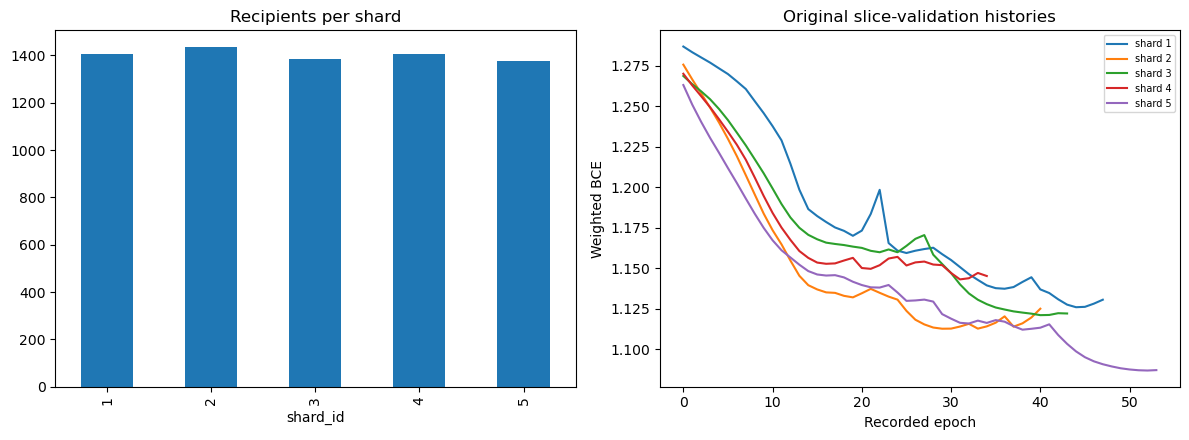

In [35]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
shard_summary.plot.bar(x="shard_id",y="recipients",ax=axes[0],legend=False,title="Recipients per shard")
for shard_id in range(1,N_SHARDS+1):
    part=original_training_history.loc[original_training_history["shard_id"].eq(shard_id)]
    axes[1].plot(np.arange(len(part)),part["validation_weighted_bce"],label=f"shard {shard_id}")
axes[1].set(title="Original slice-validation histories",xlabel="Recorded epoch",ylabel="Weighted BCE")
axes[1].legend(fontsize=7); fig.tight_layout()
fig.savefig(FIGURE_DIR/"sisa_structure_and_training.png",dpi=160,bbox_inches="tight"); plt.show()

## 4.11 Section 4 findings

This section reports the decisive structural negative finding prominently. The corrected replay is also classified precisely from its executed audit evidence.

In [36]:
affected_total = int(scenario_ensemble_manifest_summary["affected_shards"].sum())
replayed_total = int(scenario_shard_impact["replayed_slice_stages"].sum())
structural_finding = (
    f"Original SISA preparation trained **25 checkpoints** in **{preparation_seconds:.2f}s**, using "
    f"**{original_storage_bytes / 1e6:.2f} MB**. Every deletion scenario affected all **5 shards**, "
    "the earliest affected slice was **slice 1** in every shard, each request replayed all **25 shard/slice "
    "stages**, and **0 original final shard models** were reused. The distributed deletion requests and "
    "random recipient sharding spread forgotten rows across every shard. Consequently, this execution was "
    "five-shard **delete-first retraining**, not substantial selective suffix reuse. The corrected updated "
    "SISA models are deterministic delete-first SISA models: each starts from a fresh initialisation, uses "
    "the same original shard/slice training seeds, excludes forgotten rows, uses scenario-retained validation, "
    "and replays all five slices. Runtime savings cannot be treated as evidence that selective reuse worked."
)
display(Markdown(structural_finding))

Original SISA preparation trained **25 checkpoints** in **5.18s**, using **1.31 MB**. Every deletion scenario affected all **5 shards**, the earliest affected slice was **slice 1** in every shard, each request replayed all **25 shard/slice stages**, and **0 original final shard models** were reused. The distributed deletion requests and random recipient sharding spread forgotten rows across every shard. Consequently, this execution was five-shard **delete-first retraining**, not substantial selective suffix reuse. The corrected updated SISA models are deterministic delete-first SISA models: each starts from a fresh initialisation, uses the same original shard/slice training seeds, excludes forgotten rows, uses scenario-retained validation, and replays all five slices. Runtime savings cannot be treated as evidence that selective reuse worked.

# 5. Evaluate retained-data utility

## 5.1 Calculate individual utility metrics

The threshold and individual metric definitions match Notebooks 03 and 04. Each scenario uses only its retained test records.


In [37]:
def binary_metrics(y,p,threshold=THRESHOLD):
    pred=(p>=threshold).astype(int); tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return {"n":len(y),"positive_count":int(y.sum()),"prevalence":float(y.mean()),"threshold":threshold,
        "pr_auc":average_precision_score(y,p),"auroc":roc_auc_score(y,p),
        "balanced_accuracy":balanced_accuracy_score(y,pred),"f1":f1_score(y,pred,zero_division=0),
        "binary_cross_entropy":log_loss(y,p,labels=[0,1]),"precision":precision_score(y,pred,zero_division=0),
        "recall":recall_score(y,pred,zero_division=0),"specificity":tn/(tn+fp),"accuracy":accuracy_score(y,pred),
        "positive_prediction_rate":float(pred.mean()),"true_negative":int(tn),"false_positive":int(fp),
        "false_negative":int(fn),"true_positive":int(tp)}

test_prediction_rows=[]; sisa_metric_rows=[]
for scenario in SCENARIOS:
    frame=scenario_frames[scenario]["retained_test"].reset_index(drop=True)
    matrix=preprocessor.transform(frame[features]).astype("float32"); y=frame[target].to_numpy()
    original=aggregate_models(original_models,matrix); updated=scenario_probabilities[scenario]["retained_test"]
    test_prediction_rows.append(pd.DataFrame({"scenario":scenario,"evaluation_row":np.arange(len(frame)),
        "assessment_id":frame["assessment_id"],"true_target":y,"original_sisa_probability":original,
        "updated_sisa_probability":updated,"original_sisa_prediction":(original>=THRESHOLD).astype(int),
        "updated_sisa_prediction":(updated>=THRESHOLD).astype(int)}))
    for method,probability in [("original_sisa",original),("updated_sisa",updated)]:
        sisa_metric_rows.append({"scenario":scenario,"model":method,**binary_metrics(y,probability)})
retained_test_predictions=pd.concat(test_prediction_rows,ignore_index=True)
sisa_metrics=pd.DataFrame(sisa_metric_rows)

## 5.2 Calculate TOFU-inspired Composite Model Utility

`bce_quality = exp(-binary_cross_entropy)`. The safeguarded harmonic mean uses PR-AUC, AUROC, balanced accuracy, F1 and BCE quality unchanged.


In [38]:
reference_metrics=gradient_utility_reference.copy()
metric_columns=list(sisa_metrics.columns); reference_metrics=reference_metrics[metric_columns]
utility_metrics=pd.concat([reference_metrics,sisa_metrics],ignore_index=True)
utility_metrics["bce_quality"]=np.exp(-utility_metrics["binary_cross_entropy"])
components=["pr_auc","auroc","balanced_accuracy","f1","bce_quality"]
def harmonic(values,epsilon=1e-12):
    values=np.asarray(values,dtype=float); return float(len(values)/np.sum(1/np.maximum(values,epsilon)))
utility_metrics["composite_model_utility"]=utility_metrics[components].apply(harmonic,axis=1)
composite_model_utility=utility_metrics[["scenario","model",*components,"composite_model_utility"]]
assert np.allclose(composite_model_utility["composite_model_utility"],
                   composite_model_utility[components].apply(harmonic,axis=1),atol=1e-12,rtol=1e-12)

## 5.3 Compare original SISA, updated SISA and reference methods

The table includes baseline, full retraining, fine-tuning, gradient ascent, original SISA and updated SISA on identical scenario-specific rows. Full retraining is a single model; SISA is a five-model ensemble.


In [39]:
wide=utility_metrics.pivot(index="scenario",columns="model"); delta_rows=[]
delta_metrics=["pr_auc","auroc","balanced_accuracy","f1","binary_cross_entropy","bce_quality","composite_model_utility"]
for scenario in SCENARIOS:
    row={"scenario":scenario}
    for metric in delta_metrics:
        updated=wide.loc[scenario,(metric,"updated_sisa")]
        for reference in ["baseline","full_retraining","fine_tuning","gradient_ascent","original_sisa"]:
            row[f"updated_sisa_minus_{reference}_{metric}"]=updated-wide.loc[scenario,(metric,reference)]
    delta_rows.append(row)
utility_deltas=pd.DataFrame(delta_rows)
display(utility_metrics[["scenario","model",*delta_metrics]])

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,binary_cross_entropy,bce_quality,composite_model_utility
0,recipient_withdrawal,baseline,0.169267,0.731534,0.630478,0.244288,0.574755,0.562843,0.339417
1,donor_withdrawal,baseline,0.168604,0.731754,0.630475,0.244170,0.574600,0.562930,0.338853
2,hospital_removal,baseline,0.173596,0.739196,0.636655,0.252029,0.573226,0.563704,0.346601
3,invalid_consent,baseline,0.163900,0.735045,0.628857,0.237052,0.559673,0.571396,0.332878
4,retention_expiry,baseline,0.167302,0.744495,0.634281,0.252886,0.540615,0.582390,0.343208
5,recipient_withdrawal,full_retraining,0.177118,0.734572,0.628800,0.234677,0.590813,0.553877,0.340965
6,donor_withdrawal,full_retraining,0.173580,0.731609,0.633887,0.236778,0.599383,0.549150,0.338987
7,hospital_removal,full_retraining,0.176205,0.743964,0.641917,0.249229,0.590414,0.554098,0.347360
8,invalid_consent,full_retraining,0.167787,0.735362,0.637605,0.229071,0.595136,0.551488,0.331853
9,retention_expiry,full_retraining,0.162155,0.741491,0.627631,0.227008,0.585620,0.556761,0.326582


## 5.4 Compare utility across scenarios

Affected shards and replay stages accompany utility so cross-scenario differences remain descriptive.


In [40]:
scenario_structure=scenario_ensemble_manifest_summary.merge(
    scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().reset_index(),on="scenario")
utility_structure=composite_model_utility.loc[composite_model_utility["model"].eq("updated_sisa")].merge(
    scenario_structure,on="scenario")
display(utility_structure)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,affected_shards,reused_shards,manifest_model_count,replayed_slice_stages
0,recipient_withdrawal,updated_sisa,0.163630,0.716548,0.611434,0.227210,0.554592,0.325802,5,0,5,25
1,donor_withdrawal,updated_sisa,0.164515,0.716668,0.608115,0.222222,0.554224,0.324200,5,0,5,25
2,hospital_removal,updated_sisa,0.163227,0.720585,0.612194,0.230926,0.553760,0.327142,5,0,5,25
3,invalid_consent,updated_sisa,0.154873,0.717433,0.603942,0.209598,0.554492,0.310925,5,0,5,25
4,retention_expiry,updated_sisa,0.159844,0.729504,0.617039,0.226263,0.550660,0.322931,5,0,5,25


## 5.5 Section 5 findings

The utility finding is generated from the executed comparison.


In [41]:
updated_utility=utility_metrics.loc[utility_metrics["model"].eq("updated_sisa")].set_index("scenario")
original_utility=utility_metrics.loc[utility_metrics["model"].eq("original_sisa")].set_index("scenario")
utility_change=updated_utility["composite_model_utility"]-original_utility["composite_model_utility"]
display(Markdown(f"Updated-SISA composite utility changed by **{utility_change.min():+.4f}** to "
                 f"**{utility_change.max():+.4f}** relative to original SISA across scenarios. "
                 "Individual metrics remain available and no causal scenario claim is made."))

Updated-SISA composite utility changed by **-0.0030** to **+0.0020** relative to original SISA across scenarios. Individual metrics remain available and no causal scenario claim is made.

# 6. Evaluate forget quality

## 6.1 Generate predictions on training forget sets

Every SISA probability averages exactly five shard models. Baseline, full retraining, fine-tuning and gradient ascent are aligned from immutable references.


In [42]:
def record_bce(y,p):
    p=np.clip(np.asarray(p,dtype=np.float64),1e-15,1-1e-15); y=np.asarray(y,dtype=np.float64)
    return -(y*np.log(p)+(1-y)*np.log(1-p))

forget_frames=[]
for scenario in SCENARIOS:
    frame=scenario_frames[scenario]["training_forget"].reset_index(drop=True)
    matrix=preprocessor.transform(frame[features]).astype("float32"); y=frame[target].to_numpy()
    ref=gradient_forget.loc[gradient_forget["scenario"].eq(scenario)].sort_values("evaluation_row").reset_index(drop=True)
    probabilities={method:ref[f"{method}_probability"].to_numpy(dtype=np.float64)
        for method in ["baseline","full_retraining","fine_tuning","gradient_ascent"]}
    probabilities["original_sisa"]=aggregate_models(original_models,matrix)
    probabilities["updated_sisa"]=scenario_probabilities[scenario]["training_forget"]
    output=pd.DataFrame({"scenario":scenario,"evaluation_row":np.arange(len(frame)),
                         "assessment_id":frame["assessment_id"],"true_target":y})
    for method,probability in probabilities.items():
        output[f"{method}_probability"]=probability; output[f"{method}_prediction"]=(probability>=THRESHOLD).astype(int)
        output[f"{method}_per_record_bce"]=record_bce(y,probability)
    forget_frames.append(output)
forget_set_predictions=pd.concat(forget_frames,ignore_index=True)

## 6.2 Calculate truth-ratio distributions

The established binary truth-ratio definition and epsilon are reused exactly.


In [43]:
truth_frames=[]
for method in ["baseline","full_retraining","fine_tuning","gradient_ascent","original_sisa","updated_sisa"]:
    probability=forget_set_predictions[f"{method}_probability"].to_numpy(dtype=np.float64)
    y=forget_set_predictions["true_target"].to_numpy(dtype=np.int64)
    p_true=np.where(y==1,probability,1-probability); p_incorrect=1-p_true
    ratio=(p_incorrect+EPSILON)/(p_true+EPSILON)
    truth_frames.append(pd.DataFrame({"scenario":forget_set_predictions["scenario"],
        "evaluation_row":forget_set_predictions["evaluation_row"],"true_target":y,"model":method,
        "p_true":p_true,"p_incorrect":p_incorrect,"truth_ratio":ratio,"epsilon":EPSILON}))
truth_ratio_values=pd.concat(truth_frames,ignore_index=True)
truth_ratio_summary=truth_ratio_values.groupby(["scenario","model"])["truth_ratio"].agg(
    count="count",mean="mean",median="median",minimum="min",maximum="max",
    q1=lambda x:x.quantile(.25),q3=lambda x:x.quantile(.75)).reset_index()
truth_ratio_summary["interquartile_range"]=truth_ratio_summary["q3"]-truth_ratio_summary["q1"]
display(truth_ratio_summary)

,scenario,model,count,mean,median,minimum,maximum,q1,q3,interquartile_range
0,donor_withdrawal,baseline,1992,0.979881,0.906640,3.574875e-09,6.985770,0.390317,1.388092,0.997774
1,donor_withdrawal,fine_tuning,1992,1.015556,0.917704,3.442744e-09,7.737382,0.381329,1.430981,1.049652
2,donor_withdrawal,full_retraining,1992,1.065314,0.963850,1.271374e-07,7.135536,0.417091,1.516182,1.099091
3,donor_withdrawal,gradient_ascent,1992,1.028508,0.947777,4.375595e-09,7.630473,0.412730,1.448481,1.035751
4,donor_withdrawal,original_sisa,1992,0.998582,0.821947,2.557636e-02,6.392776,0.419220,1.364856,0.945636
5,donor_withdrawal,updated_sisa,1992,1.001028,0.820188,1.065278e-02,6.899903,0.390926,1.390211,0.999284
6,hospital_removal,baseline,4314,0.935517,0.810691,1.652883e-09,8.626322,0.310622,1.343399,1.032777
7,hospital_removal,fine_tuning,4314,0.969649,0.823250,1.504561e-09,9.838072,0.309193,1.390201,1.081007
8,hospital_removal,full_retraining,4314,1.011090,0.882400,4.613736e-09,10.233602,0.308297,1.430740,1.122443
9,hospital_removal,gradient_ascent,4314,1.052714,0.899327,2.670830e-09,10.906816,0.338006,1.494859,1.156853


## 6.3 Calculate TOFU-style Forget Quality

Two-sided KS tests compare updated SISA with full retraining. Higher p-values mean less evidence of difference; lower statistics mean smaller observed distance. Neither proves equivalence, erasure or privacy.


In [44]:
quality_rows=[]
for scenario in SCENARIOS:
    part=truth_ratio_values.loc[truth_ratio_values["scenario"].eq(scenario)]
    updated=part.loc[part["model"].eq("updated_sisa"),"truth_ratio"]
    full=part.loc[part["model"].eq("full_retraining"),"truth_ratio"]
    result=ks_2samp(updated,full,alternative="two-sided",method="auto")
    quality_rows.append({"scenario":scenario,"forget_rows":len(updated),
        "tofu_style_forget_quality":float(result.pvalue),"ks_statistic":float(result.statistic)})
forget_quality_core=pd.DataFrame(quality_rows); display(forget_quality_core)

,scenario,forget_rows,tofu_style_forget_quality,ks_statistic
0,recipient_withdrawal,426,5.223776e-08,0.201878
1,donor_withdrawal,1992,3.823741e-22,0.158133
2,hospital_removal,4314,1.002409e-75,0.199815
3,invalid_consent,4148,4.047869e-08,0.065333
4,retention_expiry,6262,8.091535e-45,0.127595


## 6.4 Examine supporting forget behaviour

Supporting differences compare updated SISA with full retraining, original SISA, fine-tuning and gradient ascent.


In [45]:
support=[]
for scenario in SCENARIOS:
    part=forget_set_predictions.loc[forget_set_predictions["scenario"].eq(scenario)]
    updated=part["updated_sisa_probability"]; full=part["full_retraining_probability"]
    original=part["original_sisa_probability"]
    support.append({"scenario":scenario,
        "mean_absolute_probability_difference_from_full":np.mean(np.abs(updated-full)),
        "median_absolute_probability_difference_from_full":np.median(np.abs(updated-full)),
        "prediction_agreement_with_full":np.mean(part["updated_sisa_prediction"]==part["full_retraining_prediction"]),
        "mean_absolute_loss_difference_from_full":np.mean(np.abs(part["updated_sisa_per_record_bce"]-part["full_retraining_per_record_bce"])),
        "mean_probability_change_from_original_sisa":np.mean(updated-original),
        "prediction_changed_from_original_sisa_pct":100*np.mean(part["updated_sisa_prediction"]!=part["original_sisa_prediction"]),
        "mean_absolute_probability_difference_from_fine_tuning":np.mean(np.abs(updated-part["fine_tuning_probability"])),
        "mean_absolute_probability_difference_from_gradient_ascent":np.mean(np.abs(updated-part["gradient_ascent_probability"]))})
forget_quality=forget_quality_core.merge(pd.DataFrame(support),on="scenario")

## 6.5 Compare forget quality across scenarios

KS statistic is the primary cross-scenario distance and is shown with affected shards and replayed stages.


In [46]:
forget_quality=forget_quality.merge(scenario_structure,on="scenario")
display(forget_quality[["scenario","forget_rows","ks_statistic","tofu_style_forget_quality",
                        "affected_shards","replayed_slice_stages"]])

,scenario,forget_rows,ks_statistic,tofu_style_forget_quality,affected_shards,replayed_slice_stages
0,recipient_withdrawal,426,0.201878,5.223776e-08,5,25
1,donor_withdrawal,1992,0.158133,3.823741e-22,5,25
2,hospital_removal,4314,0.199815,1.002409e-75,5,25
3,invalid_consent,4148,0.065333,4.047869e-08,5,25
4,retention_expiry,6262,0.127595,8.091535e-45,5,25


## 6.6 Section 6 findings

The executed findings do not feed back into the frozen SISA configuration.


In [47]:
detectable=int(forget_quality["tofu_style_forget_quality"].lt(.05).sum())
lines=[f"{row.scenario.replace('_',' ')}: KS={row.ks_statistic:.4f}, p={row.tofu_style_forget_quality:.4g}"
       for row in forget_quality.itertuples()]
display(Markdown("Updated SISA versus full retraining: "+"; ".join(lines)+f". Differences were detectable "
                 f"at p<0.05 in **{detectable}** scenarios. Settings remained unchanged."))

Updated SISA versus full retraining: recipient withdrawal: KS=0.2019, p=5.224e-08; donor withdrawal: KS=0.1581, p=3.824e-22; hospital removal: KS=0.1998, p=1.002e-75; invalid consent: KS=0.0653, p=4.048e-08; retention expiry: KS=0.1276, p=8.092e-45. Differences were detectable at p<0.05 in **5** scenarios. Settings remained unchanged.

# 7. Compare efficiency and trade-offs

## 7.1 Compare preparation and deletion-time cost

Initial SISA preparation is separated from each selective replay. Deletion time is compared with full retraining, fine-tuning and gradient ascent using a descriptive 1.10× meaningful-speedup threshold.


In [48]:
efficiency=deletion_time_summary.merge(full_training[["scenario","training_seconds"]].rename(
    columns={"training_seconds":"full_retraining_seconds"}),on="scenario").merge(
    fine_training[["scenario","training_seconds"]].rename(columns={"training_seconds":"fine_tuning_seconds"}),on="scenario").merge(
    gradient_training[["scenario","training_seconds"]].rename(columns={"training_seconds":"gradient_ascent_seconds"}),on="scenario")
for method in ["full_retraining","fine_tuning","gradient_ascent"]:
    efficiency[f"speed_up_vs_{method}"]=efficiency[f"{method}_seconds"]/efficiency["selective_retraining_seconds"]
    efficiency[f"time_reduction_pct_vs_{method}"]=100*(efficiency[f"{method}_seconds"]-
        efficiency["selective_retraining_seconds"])/efficiency[f"{method}_seconds"]
display(efficiency)

,scenario,selective_retraining_seconds,full_retraining_seconds,fine_tuning_seconds,gradient_ascent_seconds,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,4.548971,4.068141,1.053696,0.192994,0.894299,-11.819406,0.231634,-331.715641,0.042426,-2257.051849
1,donor_withdrawal,7.678358,3.516527,0.876984,0.418321,0.457979,-118.350595,0.114215,-775.541483,0.054481,-1735.519001
2,hospital_removal,9.183650,3.963633,0.908980,0.586547,0.431597,-131.697768,0.098978,-910.324764,0.063869,-1465.714819
3,invalid_consent,5.730875,3.567671,1.325088,0.665100,0.622535,-60.633515,0.231219,-332.490037,0.116056,-761.656606
4,retention_expiry,5.849947,3.293482,3.240828,0.895052,0.562994,-77.621918,0.553993,-80.507792,0.153002,-553.587195


In [49]:
MEANINGFUL_SPEEDUP=1.10
def interpret_speed(value):
    if value>=MEANINGFUL_SPEEDUP:return "meaningfully faster"
    if value>1:return "slightly faster, no meaningful advantage"
    if np.isclose(value,1,atol=.01):return "approximately equal"
    return "slower"
runtime_lines=[]
for row in efficiency.itertuples():
    runtime_lines.append(f"- **{row.scenario.replace('_',' ').capitalize()}**: {row.selective_retraining_seconds:.2f}s; "
        f"{row.speed_up_vs_full_retraining:.2f}× vs full retraining ({interpret_speed(row.speed_up_vs_full_retraining)}); "
        f"{row.speed_up_vs_fine_tuning:.2f}× vs fine-tuning ({interpret_speed(row.speed_up_vs_fine_tuning)}); "
        f"{row.speed_up_vs_gradient_ascent:.2f}× vs gradient ascent ({interpret_speed(row.speed_up_vs_gradient_ascent)}).")
runtime_summary="\n".join(runtime_lines); display(Markdown(runtime_summary))

- **Recipient withdrawal**: 4.55s; 0.89× vs full retraining (slower); 0.23× vs fine-tuning (slower); 0.04× vs gradient ascent (slower).
- **Donor withdrawal**: 7.68s; 0.46× vs full retraining (slower); 0.11× vs fine-tuning (slower); 0.05× vs gradient ascent (slower).
- **Hospital removal**: 9.18s; 0.43× vs full retraining (slower); 0.10× vs fine-tuning (slower); 0.06× vs gradient ascent (slower).
- **Invalid consent**: 5.73s; 0.62× vs full retraining (slower); 0.23× vs fine-tuning (slower); 0.12× vs gradient ascent (slower).
- **Retention expiry**: 5.85s; 0.56× vs full retraining (slower); 0.55× vs fine-tuning (slower); 0.15× vs gradient ascent (slower).

## 7.2 Plot Model Utility against forget distance

Updated SISA, fine-tuning and gradient ascent use distinct markers. Lower KS is better; p-value is not the cross-scenario axis.


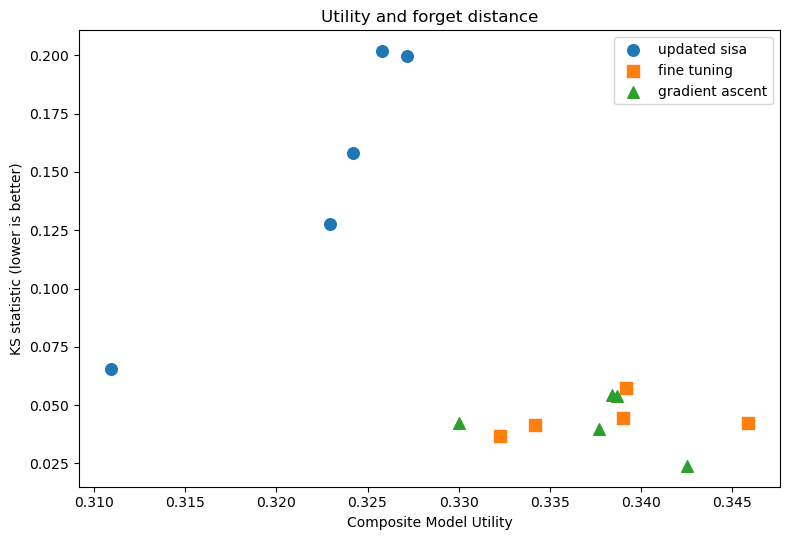

In [50]:
trade=[]
for method,quality in [("updated_sisa",forget_quality_core),("fine_tuning",fine_quality),("gradient_ascent",gradient_quality)]:
    utility=composite_model_utility.loc[composite_model_utility["model"].eq(method),
                                        ["scenario","composite_model_utility"]]
    trade.append(utility.merge(quality[["scenario","ks_statistic"]],on="scenario").assign(method=method))
trade_plot=pd.concat(trade,ignore_index=True); fig,ax=plt.subplots(figsize=(8,5.5))
for method,marker in [("updated_sisa","o"),("fine_tuning","s"),("gradient_ascent","^")]:
    part=trade_plot.loc[trade_plot["method"].eq(method)]
    ax.scatter(part["composite_model_utility"],part["ks_statistic"],marker=marker,s=70,label=method.replace("_"," "))
ax.set(xlabel="Composite Model Utility",ylabel="KS statistic (lower is better)",title="Utility and forget distance")
ax.legend(); fig.tight_layout(); fig.savefig(FIGURE_DIR/"utility_vs_forget_distance.png",dpi=160,bbox_inches="tight"); plt.show()

## 7.3 Summarise utility, forgetting and efficiency

The combined table leaves utility, forgetting, replay structure and cost as separate dimensions.


In [51]:
updated_composite=composite_model_utility.loc[composite_model_utility["model"].eq("updated_sisa")]
combined_tradeoff=updated_composite.merge(forget_quality,on="scenario").merge(efficiency,on="scenario")
display(combined_tradeoff)

,scenario,model,pr_auc,auroc,balanced_accuracy,f1,bce_quality,composite_model_utility,forget_rows,tofu_style_forget_quality,...,selective_retraining_seconds,full_retraining_seconds,fine_tuning_seconds,gradient_ascent_seconds,speed_up_vs_full_retraining,time_reduction_pct_vs_full_retraining,speed_up_vs_fine_tuning,time_reduction_pct_vs_fine_tuning,speed_up_vs_gradient_ascent,time_reduction_pct_vs_gradient_ascent
0,recipient_withdrawal,updated_sisa,0.163630,0.716548,0.611434,0.227210,0.554592,0.325802,426,5.223776e-08,...,4.548971,4.068141,1.053696,0.192994,0.894299,-11.819406,0.231634,-331.715641,0.042426,-2257.051849
1,donor_withdrawal,updated_sisa,0.164515,0.716668,0.608115,0.222222,0.554224,0.324200,1992,3.823741e-22,...,7.678358,3.516527,0.876984,0.418321,0.457979,-118.350595,0.114215,-775.541483,0.054481,-1735.519001
2,hospital_removal,updated_sisa,0.163227,0.720585,0.612194,0.230926,0.553760,0.327142,4314,1.002409e-75,...,9.183650,3.963633,0.908980,0.586547,0.431597,-131.697768,0.098978,-910.324764,0.063869,-1465.714819
3,invalid_consent,updated_sisa,0.154873,0.717433,0.603942,0.209598,0.554492,0.310925,4148,4.047869e-08,...,5.730875,3.567671,1.325088,0.665100,0.622535,-60.633515,0.231219,-332.490037,0.116056,-761.656606
4,retention_expiry,updated_sisa,0.159844,0.729504,0.617039,0.226263,0.550660,0.322931,6262,8.091535e-45,...,5.849947,3.293482,3.240828,0.895052,0.562994,-77.621918,0.553993,-80.507792,0.153002,-553.587195


## 7.4 Section 7 findings

Preparation, storage and deletion-time findings are generated from this execution.


In [52]:
meaningful_full = int((efficiency["speed_up_vs_full_retraining"] >= MEANINGFUL_SPEEDUP).sum())
mean_utility = updated_composite["composite_model_utility"].mean()
mean_ks = forget_quality["ks_statistic"].mean()
section7 = (
    f"Preparation cost was **{preparation_seconds:.2f}s** and total SISA model storage was "
    f"**{(original_storage_bytes + updated_storage_bytes) / 1e6:.2f} MB**. Mean updated utility was "
    f"**{mean_utility:.4f}** and mean KS distance **{mean_ks:.4f}**. The corrected delete-first SISA run "
    f"was meaningfully faster than the monolithic full-retraining reference in **{meaningful_full}** scenarios. "
    "However, all five shards and all 25 stages were retrained for every scenario, with no original final shard "
    "reuse. These timings therefore do **not** demonstrate a selective-reuse advantage; they may reflect five "
    "smaller ensemble members versus one larger single model, training dynamics, or early stopping. The full-"
    "retraining reference is a single model, whereas SISA is a five-model ensemble, so this is not an identical-"
    "architecture or identical-training comparison.\n\n" + runtime_summary +
    "\n\nNo arbitrary combined score is used; runtime is hardware-dependent."
)
display(Markdown(section7))

Preparation cost was **5.18s** and total SISA model storage was **2.61 MB**. Mean updated utility was **0.3222** and mean KS distance **0.1506**. The corrected delete-first SISA run was meaningfully faster than the monolithic full-retraining reference in **0** scenarios. However, all five shards and all 25 stages were retrained for every scenario, with no original final shard reuse. These timings therefore do **not** demonstrate a selective-reuse advantage; they may reflect five smaller ensemble members versus one larger single model, training dynamics, or early stopping. The full-retraining reference is a single model, whereas SISA is a five-model ensemble, so this is not an identical-architecture or identical-training comparison.

- **Recipient withdrawal**: 4.55s; 0.89× vs full retraining (slower); 0.23× vs fine-tuning (slower); 0.04× vs gradient ascent (slower).
- **Donor withdrawal**: 7.68s; 0.46× vs full retraining (slower); 0.11× vs fine-tuning (slower); 0.05× vs gradient ascent (slower).
- **Hospital removal**: 9.18s; 0.43× vs full retraining (slower); 0.10× vs fine-tuning (slower); 0.06× vs gradient ascent (slower).
- **Invalid consent**: 5.73s; 0.62× vs full retraining (slower); 0.23× vs fine-tuning (slower); 0.12× vs gradient ascent (slower).
- **Retention expiry**: 5.85s; 0.56× vs full retraining (slower); 0.55× vs fine-tuning (slower); 0.15× vs gradient ascent (slower).

No arbitrary combined score is used; runtime is hardware-dependent.

# 8. Save and verify the SISA artifacts

## 8.1 Save original and updated models

Twenty-five original model-and-optimizer checkpoints and only final affected-shard updates already exist. Original and five scenario manifests use relative paths and exactly five ensemble positions.


In [53]:
assert len(original_checkpoint_paths)==25
assert all("model_state_dict" in torch.load(path,weights_only=False) and
           "optimizer_state_dict" in torch.load(path,weights_only=False) for path in original_checkpoint_paths)
assert all(len(manifest["models"])==5 and all(not Path(item["model_path"]).is_absolute() for item in manifest["models"])
           for manifest in scenario_manifests.values())

## 8.2 Save and verify results

Saving and each audit stage are separated. Per-shard probability arrays are represented by canonical float64 fingerprints rather than enormous raw tables.


In [54]:
outputs = {"shard_summary.csv": shard_summary, "slice_summary.csv": slice_summary,
    "assignment_validation.csv": assignment_validation, "original_training_history.csv": original_training_history,
    "original_training_summary.csv": original_training_summary, "original_ensemble_predictions.csv": original_ensemble_predictions,
    "scenario_shard_impact.csv": scenario_shard_impact, "selective_retraining_history.csv": selective_retraining_history,
    "selective_retraining_summary.csv": selective_retraining_summary,
    "scenario_ensemble_manifest_summary.csv": scenario_ensemble_manifest_summary,
    "replay_seed_audit.csv": replay_seed_audit, "delete_first_verification.csv": delete_first_verification,
    "retained_test_predictions.csv": retained_test_predictions, "utility_metrics.csv": utility_metrics,
    "composite_model_utility.csv": composite_model_utility, "utility_deltas.csv": utility_deltas,
    "forget_set_predictions.csv": forget_set_predictions, "truth_ratio_values.csv": truth_ratio_values,
    "truth_ratio_summary.csv": truth_ratio_summary, "forget_quality.csv": forget_quality,
    "efficiency_comparison.csv": efficiency, "combined_tradeoff.csv": combined_tradeoff,
    "shard_probability_fingerprints.csv": shard_probability_fingerprints}
for name, frame in outputs.items():
    frame.to_csv(RESULT_DIR / name, index=False, float_format="%.17g")

In [55]:
# 1. Assignment readback
saved_assignment=pd.read_csv(ASSIGNMENT_PATH)
assignment_readback_pass=saved_assignment.equals(assignment)
assert assignment_readback_pass

In [56]:
# 2. Assignment reproduction
assignment_reproduction_pass = saved_assignment.equals(reproduced)
assignment_report = {"status": "passed" if assignment_reproduction_pass else "failed",
    "rows": len(saved_assignment), "sha256": sha256_file(ASSIGNMENT_PATH),
    "algorithm": "sha256 seed/kind/recipient modulo groups"}
_ = (RESULT_DIR / "assignment_reproduction_report.json").write_text(
    json.dumps(assignment_report, indent=2) + "\n"
)
assert assignment_reproduction_pass

In [57]:
# 3. Shard/slice coverage
coverage_pass=bool(assignment_validation["pass"].all() and len(shard_summary)==5 and len(slice_summary)==25)
assert coverage_pass

In [58]:
# 4. Original checkpoint checks
original_checkpoint_reload_pass=True
for path in original_checkpoint_paths:
    checkpoint=torch.load(path,weights_only=False); model=BaselineMLP(); model.load_state_dict(checkpoint["model_state_dict"])
    optimizer=torch.optim.AdamW(model.parameters(),lr=LEARNING_RATE,weight_decay=WEIGHT_DECAY)
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    original_checkpoint_reload_pass &= checkpoint["architecture"]==[24,64,32,1]
assert original_checkpoint_reload_pass

In [59]:
# 5. Scenario manifest checks
manifest_checks=[]
for scenario,manifest in scenario_manifests.items():
    paths=[ROOT/item["model_path"] for item in manifest["models"]]
    manifest_checks.append({"scenario":scenario,"five_models":len(paths)==5,
                            "all_relative":all(not Path(item["model_path"]).is_absolute() for item in manifest["models"]),
                            "all_exist":all(path.is_file() for path in paths)})
manifest_checks=pd.DataFrame(manifest_checks)
manifest_pass=bool(manifest_checks.drop(columns="scenario").to_numpy().all()); assert manifest_pass

In [60]:
# 6. Forgotten-row exclusion
forgotten_exclusion_pass=bool(forgotten_exclusion["pass"].all())
assert forgotten_exclusion_pass

In [61]:
# 7. Model and optimizer reload
def load_manifest_models(manifest):
    models = []
    for item in manifest["models"]:
        checkpoint = torch.load(ROOT / item["model_path"], weights_only=False)
        model = BaselineMLP()
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        model.eval()
        models.append(model)
    return models

reloaded_models = {scenario: load_manifest_models(manifest)
                   for scenario, manifest in scenario_manifests.items()}
model_reload_verification = pd.DataFrame([
    {"scenario": scenario, "model_count": len(models), "all_five_models_loaded": len(models) == 5}
    for scenario, models in reloaded_models.items()
])
model_reload_verification.to_csv(RESULT_DIR / "model_reload_verification.csv", index=False)
model_reload_pass = bool(model_reload_verification["all_five_models_loaded"].all())
assert model_reload_pass

In [62]:
# 8. Shard-probability fingerprint reproduction
fingerprint_rows=[]
for scenario in SCENARIOS:
    for partition in ["retained_validation","retained_test","training_forget"]:
        frame=scenario_frames[scenario][partition]; matrix=preprocessor.transform(frame[features]).astype("float32")
        aggregate_models(reloaded_models[scenario],matrix,fingerprint_rows,scenario,partition)
reproduced_fingerprints=pd.DataFrame(fingerprint_rows)
fingerprint_pass=reproduced_fingerprints.equals(shard_probability_fingerprints)
assert fingerprint_pass

In [63]:
# 9. Ensemble-probability reproduction
ensemble_rows=[]
for scenario in SCENARIOS:
    for partition,column in [("retained_test","updated_sisa_probability"),("training_forget","updated_sisa_probability")]:
        frame=scenario_frames[scenario][partition]; matrix=preprocessor.transform(frame[features]).astype("float32")
        reproduced_probability=aggregate_models(reloaded_models[scenario],matrix)
        saved_frame=retained_test_predictions if partition=="retained_test" else forget_set_predictions
        saved_probability=saved_frame.loc[saved_frame["scenario"].eq(scenario),column].to_numpy()
        ensemble_rows.append({"scenario":scenario,"partition":partition,
            "maximum_absolute_difference":float(np.max(np.abs(reproduced_probability-saved_probability))),
            "pass":np.allclose(reproduced_probability,saved_probability,atol=1e-8,rtol=1e-8)})
ensemble_probability_reproduction=pd.DataFrame(ensemble_rows)
ensemble_probability_reproduction.to_csv(RESULT_DIR/"ensemble_probability_reproduction.csv",index=False,float_format="%.17g")
ensemble_pass=bool(ensemble_probability_reproduction["pass"].all()); assert ensemble_pass

In [64]:
# 10. Utility and composite-utility reproduction from saved artifacts
saved_predictions = pd.read_csv(RESULT_DIR / "retained_test_predictions.csv")
saved_utility = pd.read_csv(RESULT_DIR / "utility_metrics.csv")
saved_composite = pd.read_csv(RESULT_DIR / "composite_model_utility.csv")
metric_names = ["n", "positive_count", "prevalence", "threshold", "pr_auc", "auroc",
    "balanced_accuracy", "f1", "binary_cross_entropy", "precision", "recall", "specificity",
    "accuracy", "positive_prediction_rate", "true_negative", "false_positive", "false_negative", "true_positive"]
reproduction_rows = []
for scenario in SCENARIOS:
    predictions = saved_predictions.loc[saved_predictions["scenario"].eq(scenario)]
    for model, probability_column in [("original_sisa", "original_sisa_probability"),
                                      ("updated_sisa", "updated_sisa_probability")]:
        calculated = binary_metrics(
            predictions["true_target"].to_numpy(), predictions[probability_column].to_numpy()
        )
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        for metric in metric_names:
            expected, actual = float(saved_row[metric]), float(calculated[metric])
            tolerance = 0.0 if metric in {"n", "positive_count", "true_negative", "false_positive",
                                           "false_negative", "true_positive"} else 1e-8
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": expected, "recalculated_value": actual, "absolute_difference": abs(expected - actual),
                "tolerance": tolerance, "pass": bool(np.isclose(expected, actual, atol=tolerance, rtol=0))})

In [65]:
for scenario in SCENARIOS:
    for model in ["original_sisa", "updated_sisa"]:
        saved_row = saved_utility.loc[
            saved_utility["scenario"].eq(scenario) & saved_utility["model"].eq(model)
        ].iloc[0]
        saved_composite_row = saved_composite.loc[
            saved_composite["scenario"].eq(scenario) & saved_composite["model"].eq(model)
        ].iloc[0]
        bce_quality = float(np.exp(-saved_row["binary_cross_entropy"]))
        composite = harmonic([saved_row["pr_auc"], saved_row["auroc"], saved_row["balanced_accuracy"],
                              saved_row["f1"], bce_quality])
        for metric, expected, actual in [
            ("bce_quality", saved_composite_row["bce_quality"], bce_quality),
            ("composite_model_utility", saved_composite_row["composite_model_utility"], composite),
        ]:
            reproduction_rows.append({"scenario": scenario, "model": model, "metric": metric,
                "saved_value": float(expected), "recalculated_value": float(actual),
                "absolute_difference": abs(float(expected) - float(actual)), "tolerance": 1e-8,
                "pass": bool(np.isclose(expected, actual, atol=1e-8, rtol=0))})
utility_metric_reproduction = pd.DataFrame(reproduction_rows)
utility_metric_reproduction.to_csv(
    RESULT_DIR / "utility_metric_reproduction.csv", index=False, float_format="%.17g"
)
base_metric_pass = bool(utility_metric_reproduction.loc[
    ~utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
composite_utility_reproduction_pass = bool(utility_metric_reproduction.loc[
    utility_metric_reproduction["metric"].isin(["bce_quality", "composite_model_utility"]), "pass"].all())
utility_reproduction_pass = base_metric_pass and composite_utility_reproduction_pass
assert utility_reproduction_pass

In [66]:
# 11. Truth-ratio reproduction
saved_truth=pd.read_csv(RESULT_DIR/"truth_ratio_values.csv")
reproduced_ratio=(saved_truth["p_incorrect"]+saved_truth["epsilon"])/(saved_truth["p_true"]+saved_truth["epsilon"])
ratio_difference=np.abs(saved_truth["truth_ratio"]-reproduced_ratio)
truth_ratio_pass=bool(np.allclose(saved_truth["truth_ratio"],reproduced_ratio,atol=1e-8,rtol=0))
truth_ratio_diagnostic=pd.DataFrame([{"rows":len(saved_truth),"maximum_absolute_difference":float(ratio_difference.max()),
                                     "required_tolerance":1e-8,"pass":truth_ratio_pass}])
truth_ratio_diagnostic.to_csv(RESULT_DIR/"truth_ratio_reproduction_diagnostic.csv",index=False,float_format="%.17g")
assert truth_ratio_pass

In [67]:
# 12. KS reproduction
saved_quality=pd.read_csv(RESULT_DIR/"forget_quality.csv").set_index("scenario"); ks_pass=True
for scenario in SCENARIOS:
    part=saved_truth.loc[saved_truth["scenario"].eq(scenario)]
    result=ks_2samp(part.loc[part["model"].eq("updated_sisa"),"truth_ratio"],
                    part.loc[part["model"].eq("full_retraining"),"truth_ratio"])
    ks_pass &= np.isclose(result.statistic,saved_quality.loc[scenario,"ks_statistic"],atol=1e-12,rtol=1e-12)
    ks_pass &= np.isclose(result.pvalue,saved_quality.loc[scenario,"tofu_style_forget_quality"],atol=1e-12,rtol=1e-12)
assert ks_pass

In [68]:
# 13. Threshold and feature checks
threshold_feature_pass=THRESHOLD==.62 and features==baseline_config["classifier_features"] and direct_fields.isdisjoint(features)
assert threshold_feature_pass

In [69]:
# 14. Leakage checks
leakage_fields = direct_fields | {target, "membership_type"}
target_absent_from_features = target not in features
leakage_pass = (leakage_fields.isdisjoint(features)
                and {"shard_id", "slice_id"}.isdisjoint(features)
                and target_absent_from_features)
assert target_absent_from_features and leakage_pass

In [70]:
# 15. Protected-hash checks
input_hashes_after = {path.relative_to(ROOT).as_posix(): sha256_file(path) for path in protected_paths}
protected_hash_pass = input_hashes_before == input_hashes_after
original_hashes_after = {path.name: sha256_file(path) for path in original_checkpoint_paths}
unchanged_original_shards_pass = original_checkpoint_hashes == original_hashes_after
artifact_integrity = {"protected_inputs_unchanged": protected_hash_pass,
    "original_checkpoints_unchanged_after_replay": unchanged_original_shards_pass,
    "protected_file_count": len(input_hashes_before), "before": input_hashes_before, "after": input_hashes_after}
_ = (RESULT_DIR / "artifact_integrity_report.json").write_text(
    json.dumps(artifact_integrity, indent=2) + "\n"
)
assert protected_hash_pass and unchanged_original_shards_pass

In [71]:
# 16. Required-artifact checks
required = [ASSIGNMENT_PATH, ORIGINAL_DIR / "ensemble_manifest.json", ORIGINAL_DIR / "configuration.json",
    RESULT_DIR / "assignment_reproduction_report.json", RESULT_DIR / "artifact_integrity_report.json",
    RESULT_DIR / "model_reload_verification.csv", RESULT_DIR / "ensemble_probability_reproduction.csv",
    RESULT_DIR / "truth_ratio_reproduction_diagnostic.csv", RESULT_DIR / "utility_metric_reproduction.csv",
    RESULT_DIR / "replay_seed_audit.csv", RESULT_DIR / "delete_first_verification.csv",
    FIGURE_DIR / "sisa_structure_and_training.png", FIGURE_DIR / "utility_vs_forget_distance.png",
    RESULT_DIR / "run_summary.json"]
required += [RESULT_DIR / name for name in outputs]
required += original_checkpoint_paths
required += [UNLEARNED_DIR / scenario / name for scenario in SCENARIOS
             for name in ["ensemble_manifest.json", "configuration.json"]]
required_artifact_pass = all(path.is_file() for path in required)
assert required_artifact_pass

In [72]:
# 17. Final acceptance
acceptance = pd.DataFrame([
    {"requirement": "Dependency and alignment gate", "pass": bool(artifact_checks["pass"].all())},
    {"requirement": "Assignment readback and reproduction", "pass": assignment_readback_pass and assignment_reproduction_pass},
    {"requirement": "Shard/slice coverage", "pass": coverage_pass},
    {"requirement": "Original checkpoints and manifests", "pass": original_checkpoint_reload_pass and manifest_pass},
    {"requirement": "Corrected deterministic delete-first replay", "pass": delete_first_verification_pass and replay_seed_audit_pass},
    {"requirement": "Forgotten-row exclusion", "pass": forgotten_exclusion_pass},
    {"requirement": "Model, fingerprint and ensemble reproduction", "pass": model_reload_pass and fingerprint_pass and ensemble_pass},
    {"requirement": "Saved utility and composite reproduction", "pass": utility_reproduction_pass},
    {"requirement": "Truth-ratio and KS reproduction", "pass": truth_ratio_pass and ks_pass},
    {"requirement": "Threshold, features and leakage", "pass": threshold_feature_pass and leakage_pass and target_absent_from_features},
    {"requirement": "Protected and original hashes", "pass": protected_hash_pass and unchanged_original_shards_pass},
    {"requirement": "Required artifacts", "pass": required_artifact_pass},
])
acceptance["status"] = acceptance["pass"].map({True: "PASS", False: "FAIL"})
display(acceptance.drop(columns="pass"))
assert acceptance["pass"].all()

,requirement,status
0,Dependency and alignment gate,PASS
1,Assignment readback and reproduction,PASS
2,Shard/slice coverage,PASS
3,Original checkpoints and manifests,PASS
4,Corrected deterministic delete-first replay,PASS
5,Forgotten-row exclusion,PASS
6,"Model, fingerprint and ensemble reproduction",PASS
7,Saved utility and composite reproduction,PASS
8,Truth-ratio and KS reproduction,PASS
9,"Threshold, features and leakage",PASS


## 8.3 Section 8 findings

The finding is generated from final acceptance.


In [73]:
max_reload=ensemble_probability_reproduction["maximum_absolute_difference"].max()
display(Markdown(f"All **{len(acceptance)}** final acceptance requirements passed. Assignment, 25 original "
    f"checkpoints, five scenario manifests, replay exclusion, shard fingerprints and ensemble probabilities reproduced. "
    f"Maximum ensemble reload difference was **{max_reload:.2e}**; utility, truth ratios, KS and protected hashes reconciled."))

All **12** final acceptance requirements passed. Assignment, 25 original checkpoints, five scenario manifests, replay exclusion, shard fingerprints and ensemble probabilities reproduced. Maximum ensemble reload difference was **0.00e+00**; utility, truth ratios, KS and protected hashes reconciled.

# 9. Conclusions and limitations

## 9.1 Main findings

The conclusion is generated from current preparation, structure, utility, forgetting, efficiency and storage results.


In [74]:
mean_original = composite_model_utility.loc[
    composite_model_utility["model"].eq("original_sisa"), "composite_model_utility"].mean()
mean_updated = composite_model_utility.loc[
    composite_model_utility["model"].eq("updated_sisa"), "composite_model_utility"].mean()
mean_utility_difference = mean_updated - mean_original
scenario_utility_changes = (
    composite_model_utility.loc[composite_model_utility["model"].eq("updated_sisa")]
    .set_index("scenario")["composite_model_utility"]
    - composite_model_utility.loc[composite_model_utility["model"].eq("original_sisa")]
    .set_index("scenario")["composite_model_utility"]
)
mean_utility_interpretation = (
    "essentially unchanged on average"
    if abs(mean_utility_difference) < 1e-4 else "changed on average"
)
section9 = (
    f"SISA preparation took **{preparation_seconds:.2f}s** and stored 25 original checkpoints. Every scenario "
    "affected all five shards at slice 1, replayed all 25 stages and reused no original final shard model. This "
    "is a structural negative finding: the distributed deletion requests and random recipient sharding produced "
    "five-shard delete-first retraining, not substantial selective reuse. "
    f"Mean Composite Model Utility was **{mean_original:.6f}** for original SISA and **{mean_updated:.6f}** "
    f"for updated SISA, a signed difference of **{mean_utility_difference:+.6f}**; it was therefore "
    f"**{mean_utility_interpretation}**. Scenario-specific changes ranged from "
    f"**{scenario_utility_changes.min():+.6f}** to **{scenario_utility_changes.max():+.6f}**, so individual "
    f"scenarios both improved and declined. Mean updated-SISA KS distance from full retraining was "
    f"**{mean_ks:.4f}**. The corrected updated SISA is deterministic delete-first SISA after fresh-"
    "initialisation, same-slice-seed, forget-exclusion, scenario-validation and all-slice checks. The KS "
    "comparison is useful because it applies a common measure, but it cannot isolate deletion fidelity from "
    "the architecture difference between a five-model SISA ensemble and the single full-retraining model. Poor "
    "similarity is therefore not proof that deleted data remain memorised. Any runtime savings may instead "
    "reflect five smaller models, training dynamics or early stopping, and are not evidence that selective reuse "
    f"worked. Total SISA model storage was **{(original_storage_bytes + updated_storage_bytes) / 1e6:.2f} MB**."
)
display(Markdown(section9))

SISA preparation took **5.18s** and stored 25 original checkpoints. Every scenario affected all five shards at slice 1, replayed all 25 stages and reused no original final shard model. This is a structural negative finding: the distributed deletion requests and random recipient sharding produced five-shard delete-first retraining, not substantial selective reuse. Mean Composite Model Utility was **0.322124** for original SISA and **0.322200** for updated SISA, a signed difference of **+0.000076**; it was therefore **essentially unchanged on average**. Scenario-specific changes ranged from **-0.002972** to **+0.001991**, so individual scenarios both improved and declined. Mean updated-SISA KS distance from full retraining was **0.1506**. The corrected updated SISA is deterministic delete-first SISA after fresh-initialisation, same-slice-seed, forget-exclusion, scenario-validation and all-slice checks. The KS comparison is useful because it applies a common measure, but it cannot isolate deletion fidelity from the architecture difference between a five-model SISA ensemble and the single full-retraining model. Poor similarity is therefore not proof that deleted data remain memorised. Any runtime savings may instead reflect five smaller models, training dynamics or early stopping, and are not evidence that selective reuse worked. Total SISA model storage was **2.61 MB**.

## 9.2 Limitations

This generated-data study uses one split, seed and SISA configuration. The five-shard/five-slice choice, hash assignment and artificial slice order affect results. In this execution every distributed deletion request reached all five randomly assigned recipient shards at slice 1, so all 25 stages were replayed and no original final shard was reused. This is five-shard delete-first retraining, not evidence of substantial selective reuse; observed runtime differences may arise from five smaller models, training dynamics or early stopping.

The monolithic full-retraining reference is one model, while SISA is a five-model ensemble, so their architectures and training procedures are not identical. The common truth-ratio KS comparison is informative but cannot isolate deletion fidelity from that architecture difference. Poor SISA/full-retraining similarity does not prove that deleted data remain memorised. The shared baseline preprocessor is not unlearned. Full retraining remains a heuristic reference; binary TOFU adaptation and KS tests have limitations and do not prove privacy. No privacy attack or parameter analysis is performed. Runtime is hardware-dependent, composite utility can obscure individual metrics, and no causal or clinical claim is made.

## 9.3 Role in the wider project and next step

Notebook 05 completes the method-specific experiments. Next steps are to freeze Notebooks 01–05, consolidate results, select final tables and figures, write methodology/results/discussion/limitations, and prepare reproducibility and submission instructions. No further method notebook is created here.

In [75]:
# Completed status is written only after Section 9 and every verification.
assert acceptance["pass"].all() and required_artifact_pass and protected_hash_pass
run_summary = {"status": "completed", "task": "SISA", "seed": SEED, "threshold": THRESHOLD,
    "configuration": original_configuration, "preparation_seconds": preparation_seconds,
    "original_checkpoint_count": 25, "original_storage_bytes": original_storage_bytes,
    "updated_storage_bytes": updated_storage_bytes,
    "total_model_storage_bytes": original_storage_bytes + updated_storage_bytes,
    "slice_training_seed_definition": "derived_seed('slice_training', shard_id, slice_id)",
    "slice_training_seeds": slice_training_seeds, "replay_seed_audit_pass": replay_seed_audit_pass,
    "delete_first_verification_pass": delete_first_verification_pass,
    "affected_shards": dict(zip(scenario_ensemble_manifest_summary["scenario"],
                                scenario_ensemble_manifest_summary["affected_shards"])),
    "replayed_slice_stages": scenario_shard_impact.groupby("scenario")["replayed_slice_stages"].sum().to_dict(),
    "deletion_seconds": deletion_time.to_dict(), "all_models_verified": model_reload_pass,
    "utility_metrics_reproduced": base_metric_pass,
    "composite_utility_reproduced": composite_utility_reproduction_pass,
    "maximum_ensemble_probability_difference": float(max_reload), "all_verification_checks_pass": True,
    "protected_inputs_unchanged": protected_hash_pass,
    "original_checkpoints_unchanged": unchanged_original_shards_pass, "network_requests": 0}
_ = (RESULT_DIR / "run_summary.json").write_text(json.dumps(run_summary, indent=2) + "\n")